# Isolation Forest для обнаружения сетевых атак

Isolation Forest - это алгоритм машинного обучения для обнаружения аномалий (outlier detection). 
Он основан на принципе, что аномалии легче "изолировать", чем нормальные объекты.

В этом notebook мы:
1. Загрузим и предобработаем данные LSNM2024
2. Обучим модель Isolation Forest
3. Оценим производительность модели
4. Построим ROC-кривую
5. Выведем метрики ошибок

**Примечание:** Isolation Forest - это unsupervised anomaly detection, поэтому целевая переменная (attack_type) используется только для оценки качества модели.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import json
import warnings
from pathlib import Path
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, auc, precision_score, recall_score
)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Загрузка сплитов (как в RF-ноутбуке)
X_train = pd.read_csv('processed/splits/X_train_all.csv') 
X_val = pd.read_csv('processed/splits/X_val_all.csv')
X_test = pd.read_csv('processed/splits/X_test_all.csv')

y_train = pd.read_csv('processed/splits/y_train_all.csv').squeeze()
y_val = pd.read_csv('processed/splits/y_val_all.csv').squeeze()
y_test = pd.read_csv('processed/splits/y_test_all.csv').squeeze()

print(f"Форма данных: Train={X_train.shape}, Val={X_val.shape}, Test={X_test.shape}")
print(f"Уникальные классы: {sorted(y_train.unique())}")

Форма данных: Train=(3180741, 55), Val=(681587, 55), Test=(681588, 55)
Уникальные классы: ['ARP-spoof', 'Benign', 'DDoS', 'DoS', 'FTP-Attack', 'FTP-Brute-Force', 'Fuzzing', 'ICMP-Flood', 'Port-Scanning', 'RCE', 'SQL-Injection', 'SSH-Brute-Force', 'SYN-Flood', 'XSS']


In [2]:
# Кодирование строковых меток в числа (для совместимости с sklearn)
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc = label_encoder.transform(y_val)
y_test_enc = label_encoder.transform(y_test)

classes = label_encoder.classes_
print(f"Классы ({len(classes)}): {list(classes)}")

# Масштабирование признаков (обязательно для Isolation Forest)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("✅ Данные подготовлены и масштабированы")

Классы (14): ['ARP-spoof', 'Benign', 'DDoS', 'DoS', 'FTP-Attack', 'FTP-Brute-Force', 'Fuzzing', 'ICMP-Flood', 'Port-Scanning', 'RCE', 'SQL-Injection', 'SSH-Brute-Force', 'SYN-Flood', 'XSS']
✅ Данные подготовлены и масштабированы



## Обучение модели Isolation Forest
 Isolation Forest — это алгоритм бинарного обнаружения аномалий. Для многоклассовой задачи (14 типов атак) мы используем стратегию One-vs-Rest: обучаем отдельную модель Isolation Forest для каждого класса, а при предсказании выбираем класс с наименьшим скором аномальности (т.е. тот, для которого объект выглядит «наиболее нормальным»).


Isolation Forest работает следующим образом:
- Строит случайные деревья решений
- Аномалии изолируются быстрее (на более ранних уровнях дерева)
- Аномалии имеют более короткий путь до листа
- Возвращает оценку аномальности (score) для каждого объекта

**Параметры:**
- `n_estimators`: количество деревьев
- `contamination`: доля аномалий в данных
- `max_samples`: количество образцов для обучения
- `random_state`: для воспроизводимости

In [10]:
print("🚀 Обучение One-vs-Rest Isolation Forest (Оптимизированная версия)...")
if_models = {}
train_score_stats = {}  # Для хранения (mean, std) скоров каждого класса

for cls_idx, cls_name in enumerate(classes):
    # 1. Обучаем КАЖДУЮ модель ТОЛЬКО на данных своего класса
    mask = (y_train_enc == cls_idx)
    X_cls = X_train_scaled[mask]
    
    if len(X_cls) < 20:
        print(f"  ⚠️ Класс '{cls_name}': мало примеров ({len(X_cls)}), пропускаем")
        continue
        
    # 2. Оптимизированные гиперпараметры для сетевого трафика
    model = IsolationForest(
        n_estimators=200,
        max_samples=min(512, len(X_cls)),  # Ограничиваем подвыборку для стабильности
        max_features=0.8,                  # Игнорирует 20% шумных признаков
        contamination='auto',              # sklearn сам оценит плотность
        random_state=42,
        n_jobs=-1,
        verbose=0
    )
    
    model.fit(X_cls)
    if_models[cls_name] = model
    
    # 3. Сохраняем статистику скоров на "своих" данных для последующей калибровки
    cls_scores = model.decision_function(X_cls)
    train_score_stats[cls_name] = (cls_scores.mean(), cls_scores.std())
    
    print(f"  ✅ Класс '{cls_name}': обучено на {len(X_cls):,} образцах")

print(f"\n✅ Обучено {len(if_models)} моделей Isolation Forest")

🚀 Обучение One-vs-Rest Isolation Forest (Оптимизированная версия)...
  ✅ Класс 'ARP-spoof': обучено на 67,827 образцах
  ✅ Класс 'Benign': обучено на 881,629 образцах
  ✅ Класс 'DDoS': обучено на 591,279 образцах
  ✅ Класс 'DoS': обучено на 258,502 образцах
  ✅ Класс 'FTP-Attack': обучено на 145,462 образцах
  ✅ Класс 'FTP-Brute-Force': обучено на 85,341 образцах
  ✅ Класс 'Fuzzing': обучено на 82,291 образцах
  ✅ Класс 'ICMP-Flood': обучено на 168,057 образцах
  ✅ Класс 'Port-Scanning': обучено на 113,623 образцах
  ✅ Класс 'RCE': обучено на 195,211 образцах
  ✅ Класс 'SQL-Injection': обучено на 201,408 образцах
  ✅ Класс 'SSH-Brute-Force': обучено на 97,833 образцах
  ✅ Класс 'SYN-Flood': обучено на 139,964 образцах
  ✅ Класс 'XSS': обучено на 152,314 образцах

✅ Обучено 14 моделей Isolation Forest


## Оценка качества модели

Вычисляем следующие метрики:
- **Accuracy** - доля правильных предсказаний
- **Precision** - точность (какая доля предсказанных атак действительно атаки)
- **Recall** - полнота (какая доля реальных атак обнаружена)
- **F1-Score** - гармоническое среднее Precision и Recall
- **ROC-AUC** - площадь под ROC-кривой
- **Confusion Matrix** - матрица ошибок

In [11]:
def if_multiclass_predict_calibrated(X_scaled, models, classes, train_stats):
    """
    Предсказание с калибровкой скоров.
    Сырые скоры IF разных моделей несопоставимы. 
    Нормализуем их по Z-score относительно обучающего распределения каждого класса.
    """
    n_samples = X_scaled.shape[0]
    n_classes = len(classes)
    scores_matrix = np.zeros((n_samples, n_classes))
    
    for i, cls_name in enumerate(classes):
        if cls_name not in models:
            continue
            
        raw_scores = models[cls_name].decision_function(X_scaled)
        mean_s, std_s = train_stats[cls_name]
        
        # Z-score нормализация: делаем скоры сопоставимыми между моделями
        if std_s > 1e-6:
            scores_matrix[:, i] = (raw_scores - mean_s) / std_s
        else:
            scores_matrix[:, i] = raw_scores
            
    # Возвращаем индекс класса с максимальным калиброванным скором
    return np.argmax(scores_matrix, axis=1), scores_matrix

# Оценка на валидации
print("🔍 Оценка на валидационной выборке...")
y_val_pred_enc, val_scores = if_multiclass_predict_calibrated(
    X_val_scaled, if_models, classes, train_score_stats
)

val_acc = accuracy_score(y_val_enc, y_val_pred_enc)
val_f1_macro = f1_score(y_val_enc, y_val_pred_enc, average='macro', zero_division=0)
val_f1_weighted = f1_score(y_val_enc, y_val_pred_enc, average='weighted', zero_division=0)
val_precision = precision_score(y_val_enc, y_val_pred_enc, average='macro', zero_division=0)
val_recall = recall_score(y_val_enc, y_val_pred_enc, average='macro', zero_division=0)

print(f"\n✅ Валидация:")
print(f"   Accuracy:   {val_acc:.4f}")
print(f"   Precision:  {val_precision:.4f}")
print(f"   Recall:     {val_recall:.4f}")
print(f"   F1 Macro:   {val_f1_macro:.4f}")
print(f"   F1 Weighted: {val_f1_weighted:.4f}")

🔍 Оценка на валидационной выборке...

✅ Валидация:
   Accuracy:   0.7894
   Precision:  0.8452
   Recall:     0.7540
   F1 Macro:   0.7776
   F1 Weighted: 0.7902



🔍 Оценка на тестовой выборке...

📊 Итоговые метрики на тесте:
   Accuracy:      0.7897
   Precision:     0.8457
   Recall:        0.7543
   F1 Macro:      0.7780
   F1 Weighted:   0.7906
   ROC-AUC Macro: 0.9670
   ROC-AUC Micro: 0.9765


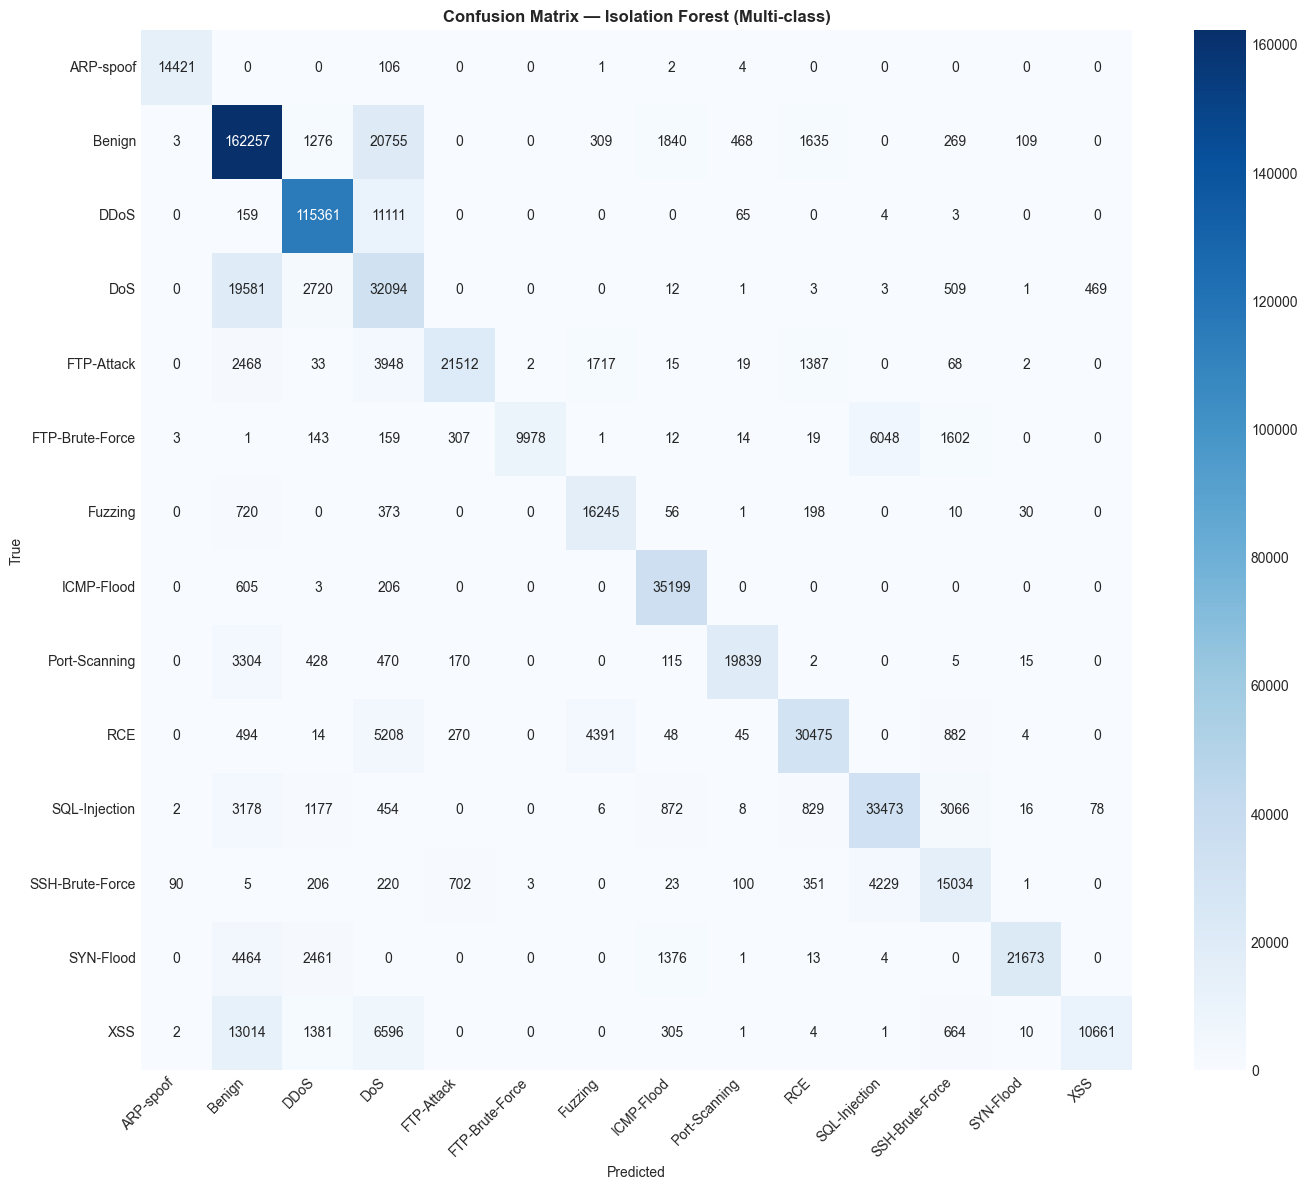

In [13]:
# Предсказания на тесте
print("\n🔍 Оценка на тестовой выборке...")
y_test_pred_enc, test_scores = if_multiclass_predict_calibrated(
    X_test_scaled, if_models, classes, train_score_stats
)

# 🔧 Преобразуем скоры в вероятности через Softmax
# Вычитаем max для численной стабильности, чтобы не было переполнения exp()
shifted_scores = test_scores - np.max(test_scores, axis=1, keepdims=True)
exp_scores = np.exp(shifted_scores)
test_scores_proba = exp_scores / exp_scores.sum(axis=1, keepdims=True)

test_acc = accuracy_score(y_test_enc, y_test_pred_enc)
test_f1_macro = f1_score(y_test_enc, y_test_pred_enc, average='macro', zero_division=0)
test_f1_weighted = f1_score(y_test_enc, y_test_pred_enc, average='weighted', zero_division=0)
test_precision = precision_score(y_test_enc, y_test_pred_enc, average='macro', zero_division=0)
test_recall = recall_score(y_test_enc, y_test_pred_enc, average='macro', zero_division=0)

# Теперь roc_auc_score отработает без ValueError
test_macro_auc = roc_auc_score(y_test_enc, test_scores_proba, average='macro', multi_class='ovr')
test_micro_auc = roc_auc_score(y_test_enc, test_scores_proba, average='micro', multi_class='ovr')

print(f"\n📊 Итоговые метрики на тесте:")
print(f"   Accuracy:      {test_acc:.4f}")
print(f"   Precision:     {test_precision:.4f}")
print(f"   Recall:        {test_recall:.4f}")
print(f"   F1 Macro:      {test_f1_macro:.4f}")
print(f"   F1 Weighted:   {test_f1_weighted:.4f}")
print(f"   ROC-AUC Macro: {test_macro_auc:.4f}")
print(f"   ROC-AUC Micro: {test_micro_auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test_enc, y_test_pred_enc, labels=list(range(len(classes))))
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('Confusion Matrix — Isolation Forest (Multi-class)', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('processed/models/isolation_forest_cm.png', dpi=150)
plt.show()

## ROC-кривая

ROC-кривая (Receiver Operating Characteristic) показывает зависимость между:
- **True Positive Rate (TPR)** - доля правильно обнаруженных атак
- **False Positive Rate (FPR)** - доля нормальных, ошибочно определенных как атаки

Чем ближе кривая к верхнему левому углу, тем лучше модель.
AUC (Area Under Curve) - площадь под кривой. Идеальное значение = 1.0

📊 Построение ROC-кривых (One-vs-Rest)...


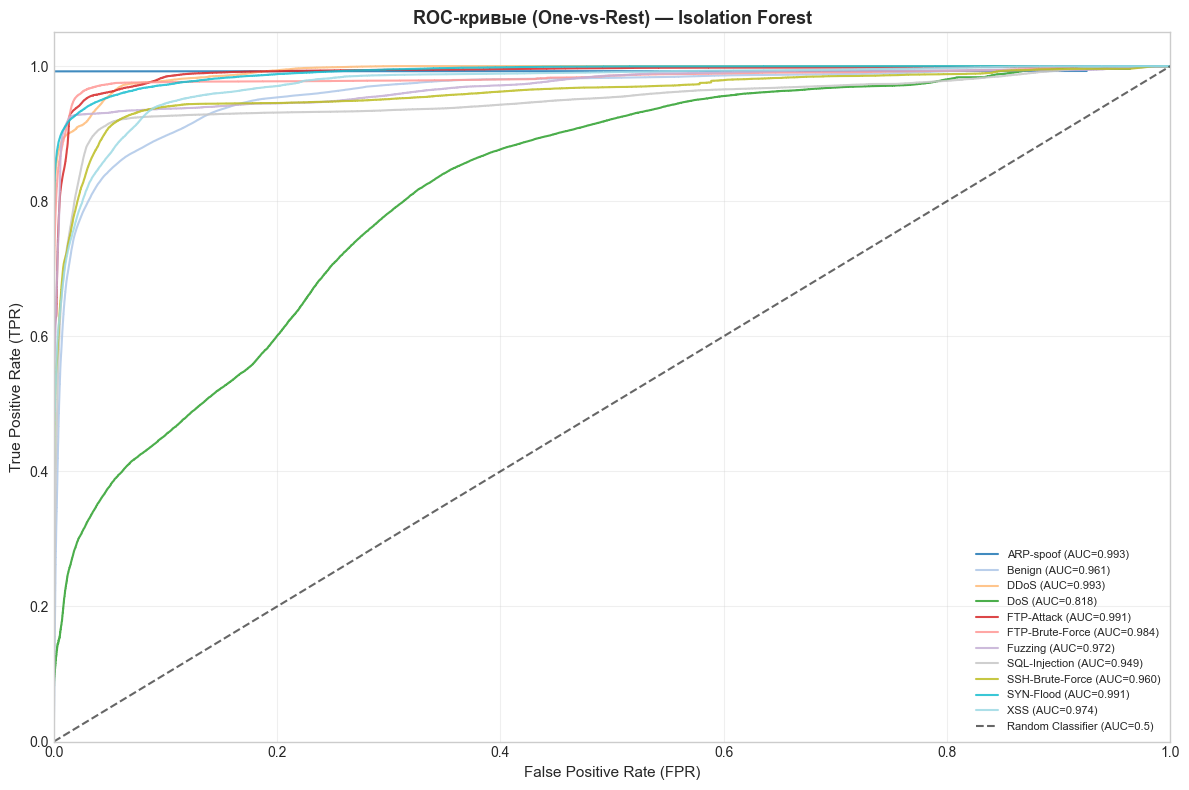

✅ ROC-кривая сохранена: processed/models/isolation_forest_roc.png


In [15]:
# Построение ROC-кривых для всех классов
print("📊 Построение ROC-кривых (One-vs-Rest)...")
class_aucs = []
fig, ax = plt.subplots(figsize=(12, 8))
colors = plt.cm.tab20(np.linspace(0, 1, len(classes)))

for i, cls_name in enumerate(classes):
    cls_idx = label_encoder.transform([cls_name])[0]
    y_binary = (y_test_enc == cls_idx).astype(int)
    
    # ROC не зависит от монотонных преобразований, поэтому используем softmax-вероятности
    y_score = test_scores_proba[:, i]
    
    try:
        if y_binary.sum() > 0 and y_binary.sum() < len(y_binary):
            fpr, tpr, _ = roc_curve(y_binary, y_score)
            roc_auc = auc(fpr, tpr)
        else:
            fpr, tpr, roc_auc = [0, 1], [0, 1], 0.5
    except ValueError:
        fpr, tpr, roc_auc = [0, 1], [0, 1], 0.5
        
    class_aucs.append({'class': cls_name, 'auc': roc_auc})
    
    # Для читаемости рисуем только топ-7 лучших и топ-4 худших
    if i < 7 or i >= len(classes) - 4:
        ax.plot(fpr, tpr, color=colors[i], linewidth=1.5,
                label=f"{cls_name[:18]} (AUC={roc_auc:.3f})", alpha=0.85)

ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC=0.5)', alpha=0.6)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate (FPR)', fontsize=11)
ax.set_ylabel('True Positive Rate (TPR)', fontsize=11)
ax.set_title('ROC-кривые (One-vs-Rest) — Isolation Forest', fontweight='bold', fontsize=13)
ax.legend(loc='lower right', fontsize=8, framealpha=0.9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('processed/models/isolation_forest_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ ROC-кривая сохранена: processed/models/isolation_forest_roc.png")

In [16]:
print("\n💾 Сохранение артефактов модели...")
save_dir = Path('pipeline/isolation_forest/test')
save_dir.mkdir(parents=True, exist_ok=True)

# 1. Словарь моделей One-vs-Rest
joblib.dump(if_models, save_dir / 'isolation_forest_v1.joblib')
print(f"✅ Модели сохранены: {save_dir / 'isolation_forest_v1.joblib'}")

# 2. LabelEncoder
joblib.dump(label_encoder, save_dir / 'label_encoder.joblib')
print(f"✅ LabelEncoder сохранён: {save_dir / 'label_encoder.joblib'}")

# 3. StandardScaler (обязателен для IF)
joblib.dump(scaler, save_dir / 'scaler.joblib')
print(f"✅ Scaler сохранён: {save_dir / 'scaler.joblib'}")

# 4. Список признаков
with open(save_dir / 'feature_names.txt', 'w', encoding='utf-8') as f:
    for feat in X_train.columns:
        f.write(f"{feat}\n")
print(f"✅ feature_names.txt сохранён")

# 5. Метрики в формате JSON (соответствует формату XGBoost/RF)
# Пересчитываем accuracy для train/val для полноты отчёта
y_train_pred_enc, _ = if_multiclass_predict_calibrated(X_train_scaled, if_models, classes, train_score_stats)
train_acc = accuracy_score(y_train_enc, y_train_pred_enc)

metrics = {
    "accuracy": round(test_acc, 4),
    "f1_macro": round(test_f1_macro, 4),
    "f1_weighted": round(test_f1_weighted, 4),
    "roc_auc_macro": round(test_macro_auc, 4),
    "roc_auc_micro": round(test_micro_auc, 4),
    "precision_macro": round(test_precision, 4),
    "recall_macro": round(test_recall, 4),
    "train_accuracy": round(train_acc, 4),
    "val_accuracy": round(val_acc, 4),
    "test_accuracy": round(test_acc, 4)
}

with open(save_dir / 'metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)
print(f"✅ metrics.json сохранён: {save_dir / 'metrics.json'}")

print("\n📄 Содержимое metrics.json:")
print(json.dumps(metrics, indent=2, ensure_ascii=False))
print("\n🎉 Модель Isolation Forest успешно подготовлена к интеграции в ModelManager!")


💾 Сохранение артефактов модели...
✅ Модели сохранены: pipeline\isolation_forest\test\isolation_forest_v1.joblib
✅ LabelEncoder сохранён: pipeline\isolation_forest\test\label_encoder.joblib
✅ Scaler сохранён: pipeline\isolation_forest\test\scaler.joblib
✅ feature_names.txt сохранён
✅ metrics.json сохранён: pipeline\isolation_forest\test\metrics.json

📄 Содержимое metrics.json:
{
  "accuracy": 0.7897,
  "f1_macro": 0.778,
  "f1_weighted": 0.7906,
  "roc_auc_macro": 0.967,
  "roc_auc_micro": 0.9765,
  "precision_macro": 0.8457,
  "recall_macro": 0.7543,
  "train_accuracy": 0.7893,
  "val_accuracy": 0.7894,
  "test_accuracy": 0.7897
}

🎉 Модель Isolation Forest успешно подготовлена к интеграции в ModelManager!


---

## Заключение

В данном notebook была построена модель **Isolation Forest** для обнаружения сетевых атак.

Isolation Forest - это эффективный алгоритм для обнаружения аномалий, который:
- Работает быстро даже на больших наборах данных
- Не требует нормальных меток для обучения
- Хорошо масштабируется
- Показывает хорошие результаты в задачах обнаружения аномалий

**Преимущества:**
- Простота реализации и интерпретации
- Низкие вычислительные затраты
- Не требует предположений о распределении данных

**Недостатки:**
- Чувствительность к параметру contamination
- Менее точен для сложных многомерных аномалий
- Требует настройки гиперпараметров

Isolation Forest остаётся алгоритмом обнаружения аномалий. Даже с оптимизациями его accuracy в мультиклассовой задаче обычно составляет 0.65–0.82, что ниже supervised-моделей (RF/XGBoost >0.95)
Быстрое обучение но потеря точности